In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)

# convert csv file into parquet file 
import polars as pl
import time

csv_filename = "../data/processed/tac_ch4_formatted_v1.csv"
parquet_filename = "../data/processed/tac_ch4_formatted_v1.parquet"

lazy_df = pl.scan_csv(csv_filename)
lazy_df.sink_parquet(parquet_filename)

In [2]:
# features
import duckdb

parquet_filename = "../data/processed/tac_ch4_formatted_v1.parquet"
duckdb.sql(f"DESCRIBE SELECT * FROM '{parquet_filename}'").df()


,column_name,column_type,null,key,default,extra
0,date,BIGINT,YES,None,None,None
1,time,BIGINT,YES,None,None,None
2,type,VARCHAR,YES,None,None,None
3,sample,VARCHAR,YES,None,None,None
4,standard,VARCHAR,YES,None,None,None
5,port,BIGINT,YES,None,None,None
6,ch4_dry,DOUBLE,YES,None,None,None
7,ch4_wet,DOUBLE,YES,None,None,None
8,ch4_stdev,DOUBLE,YES,None,None,None
9,ch4_std_rep,VARCHAR,YES,None,None,None


My note:
    ch4_dry: 乾空氣下的甲烷
    ch4_wet: 濕空氣下的甲烷
    ch4_std_rep	:甲烷標準氣體的重複量測次數
    ch4_std_stdev:甲烷標準氣體的標準差
    ch4_target_error:目標氣體誤差(愈接近0愈準)
    ch4_Cdrift:甲烷校正濃度飄移
    ch4_C:原始資料總筆數
    ch4_N: 有效計算次數	
    ch4_Nfiltered: 經過品管篩選後的最終甲烷樣本數
    cycle_time:採樣循環時間(隔多久一筆新的)
    h2o:水蒸氣濃度(測到的原始水氣百分比)
    cavity_press:光學腔體壓力
    cavity_press_stdev:腔體壓力標準差
    das_temp: 數據採集系統溫度
    etalon_temp:標準具(Etalon) 溫度。Etalon是光學儀器中的光學尺，溫度變化會導致雷射波跑掉
    warmbox_temp:恆溫箱溫度。儀器內部把學儀器包起來的箱子。
    outlet_valve: 出氣閥門控制值。控制內部壓力的。


Output: ch4_dry, ch4_wet, h20
variable: ch4_stdev, h2o_stdev, cavity_press_stdev, cavity_temp_stdev
instrument state: cavity_press, cavity_temp, das_temp, etalon_temp, warmbox_temp, cycle_time, outlet_valve

In [3]:
raw_data = duckdb.sql(f"SELECT * FROM '{parquet_filename}'").df()
raw_data.head(20)

,date,time,type,sample,standard,port,ch4_dry,ch4_wet,ch4_stdev,ch4_std_rep,ch4_std_stdev,ch4_target_error,ch4_Cdrift,ch4_C,ch4_N,ch4_Nfiltered,cycle_time,h2o,h2o_stdev,cavity_press,cavity_press_stdev,cavity_temp,cavity_temp_stdev,das_temp,etalon_temp,warmbox_temp,outlet_valve,ch4_flag
0,120111,162730,unknown,-,USN-20112109,0,1944.517,1945.109,42.208,None,None,None,1955.510,1955.527,0,100.0,3.733,-0.02232,0.00175,140.00525,0.01396,44.90277,0.01251,32.14167,44.77072,None,31442.617,x
1,120111,162830,unknown,-,USN-20112109,0,1972.043,1972.643,57.714,None,None,None,1983.192,1983.217,0,100.0,3.733,-0.02232,0.00170,140.00435,0.01518,44.92952,0.00415,32.36250,44.91882,None,31543.971,x
2,120111,162930,unknown,-,USN-20112109,0,1940.176,1940.768,65.419,None,None,None,1951.144,1951.159,0,100.0,3.733,-0.02243,0.00221,140.00513,0.01176,44.93352,0.00128,32.59792,44.99702,None,31626.549,x
3,120111,163030,unknown,-,USN-20112109,0,2021.915,2022.526,80.016,None,None,None,2033.346,2033.386,0,100.0,3.733,-0.02217,0.00256,140.00745,0.01437,44.92616,0.00253,32.81506,45.02549,None,31687.379,x
4,120111,163130,unknown,-,USN-20112109,0,1976.217,1976.825,57.151,None,None,None,1987.390,1987.416,0,100.0,3.625,-0.02259,0.00192,140.00314,0.01321,44.91914,0.00165,32.98813,45.02443,None,31726.805,x
5,120111,163230,unknown,-,USN-20112109,0,1977.023,1977.629,107.839,None,None,None,1988.200,1988.226,0,100.0,3.733,-0.02248,0.00258,139.99792,0.01910,44.91655,0.00026,33.13750,45.00900,None,31758.904,F
6,120111,163330,unknown,-,USN-20112109,0,1974.220,1974.855,94.284,None,None,None,1985.381,1985.406,0,100.0,3.500,-0.02362,0.00115,140.00032,0.01554,44.91776,0.00100,33.26172,44.98967,None,31785.496,F
7,120111,163430,unknown,-,USN-20112109,0,1904.261,1904.902,51.648,None,None,None,1915.027,1915.031,0,100.0,3.500,-0.02471,0.00000,140.00146,0.01652,44.92261,0.00181,33.35547,44.97134,None,31807.650,F
8,120111,163530,unknown,-,USN-20112109,0,1929.363,1930.012,59.736,None,None,None,1940.270,1940.282,0,100.0,3.500,-0.02471,0.00000,139.99977,0.01241,44.92999,0.00249,33.42248,44.95708,None,31827.049,F
9,120111,163630,unknown,-,USN-20112109,0,1970.042,1970.705,71.395,None,None,None,1981.180,1981.204,0,100.0,3.471,-0.02471,0.00000,140.00076,0.01586,44.93916,0.00306,33.47794,44.94679,None,31844.387,F


In [4]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{parquet_filename}'").df()


,column_name,column_type,null,key,default,extra
0,date,BIGINT,YES,None,None,None
1,time,BIGINT,YES,None,None,None
2,type,VARCHAR,YES,None,None,None
3,sample,VARCHAR,YES,None,None,None
4,standard,VARCHAR,YES,None,None,None
5,port,BIGINT,YES,None,None,None
6,ch4_dry,DOUBLE,YES,None,None,None
7,ch4_wet,DOUBLE,YES,None,None,None
8,ch4_stdev,DOUBLE,YES,None,None,None
9,ch4_std_rep,VARCHAR,YES,None,None,None


In [5]:
processed_data = raw_data.copy()

In [6]:
varchar_col = ['ch4_std_rep', 'ch4_std_stdev', 'ch4_target_error', 'warmbox_temp']
for i in varchar_col:
    processed_data[i] = pd.to_numeric(processed_data[i], errors='coerce')


In [7]:
processed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6828990 entries, 0 to 6828989
Data columns (total 28 columns):
 #   Column              Dtype  
---  ------              -----  
 0   date                int64  
 1   time                int64  
 2   type                object 
 3   sample              object 
 4   standard            object 
 5   port                int64  
 6   ch4_dry             float64
 7   ch4_wet             float64
 8   ch4_stdev           float64
 9   ch4_std_rep         float64
 10  ch4_std_stdev       float64
 11  ch4_target_error    float64
 12  ch4_Cdrift          float64
 13  ch4_C               float64
 14  ch4_N               int64  
 15  ch4_Nfiltered       float64
 16  cycle_time          float64
 17  h2o                 float64
 18  h2o_stdev           float64
 19  cavity_press        float64
 20  cavity_press_stdev  float64
 21  cavity_temp         float64
 22  cavity_temp_stdev   float64
 23  das_temp            float64
 24  etalon_temp         floa

In [8]:
processed_data.describe()

,date,time,port,ch4_dry,ch4_wet,ch4_stdev,ch4_std_rep,ch4_std_stdev,ch4_target_error,ch4_Cdrift,ch4_C,ch4_N,ch4_Nfiltered,cycle_time,h2o,h2o_stdev,cavity_press,cavity_press_stdev,cavity_temp,cavity_temp_stdev,das_temp,etalon_temp,warmbox_temp,outlet_valve
count,6.828990e+06,6.828990e+06,6.828990e+06,6.828990e+06,6.828990e+06,6.828990e+06,6.325102e+06,6.633826e+06,5.991066e+06,6.678111e+06,6.678111e+06,6.828990e+06,1.107286e+06,6.828990e+06,6.642572e+06,6.641303e+06,6.828990e+06,6.828990e+06,6.828990e+06,6.828990e+06,6.828990e+06,6.828990e+06,5.628456e+06,6.828990e+06
mean,1.841185e+05,1.180537e+05,8.818243e+00,1.985373e+03,1.971063e+03,1.782034e+00,2.389901e-01,2.325243e-01,2.458281e-01,1.991389e+03,1.991409e+03,1.327313e+01,9.818349e+01,3.748383e+00,5.550234e-01,2.489198e-03,1.399991e+02,2.038011e-02,4.500041e+01,2.618134e-04,3.564734e+01,4.503887e+01,4.500009e+01,3.357993e+04
std,3.886258e+04,6.926407e+04,1.946176e+00,7.551640e+01,7.804236e+01,7.077417e+00,6.632549e-02,6.599072e-02,6.777201e-02,7.426063e+01,7.428439e+01,6.193969e+00,1.275003e+01,8.294214e-01,5.118658e-01,1.125070e-01,7.034064e-01,1.229160e-01,3.589169e-02,4.389503e-04,2.302908e+00,2.920387e-02,1.553546e-02,1.503626e+03
min,1.201110e+05,3.000000e+01,0.000000e+00,1.176000e+00,1.175000e+00,0.000000e+00,0.000000e+00,8.100000e-02,3.400000e-02,1.179000e+00,1.179000e+00,0.000000e+00,5.000000e+00,2.333000e+00,-2.471000e-02,0.000000e+00,1.385718e+02,1.170000e-03,4.455700e+01,0.000000e+00,2.696117e+01,4.469521e+01,4.474028e+01,0.000000e+00
25%,1.506150e+05,6.003000e+04,8.000000e+00,1.937927e+03,1.919089e+03,3.000000e-01,1.930000e-01,1.870000e-01,1.940000e-01,1.945169e+03,1.945179e+03,1.300000e+01,1.000000e+02,3.353000e+00,4.700000e-02,5.000000e-04,1.399959e+02,1.386000e-02,4.499981e+01,0.000000e+00,3.385219e+01,4.502300e+01,4.500000e+01,3.320342e+04
50%,1.810270e+05,1.201300e+05,9.000000e+00,1.978377e+03,1.960246e+03,6.200000e-01,2.260000e-01,2.190000e-01,2.330000e-01,1.984064e+03,1.984074e+03,1.600000e+01,1.000000e+02,3.562000e+00,4.516100e-01,6.800000e-04,1.399989e+02,1.609000e-02,4.500000e+01,2.500000e-04,3.563237e+01,4.504300e+01,4.500000e+01,3.400734e+04
75%,2.203180e+05,1.800300e+05,1.000000e+01,2.020688e+03,2.012052e+03,1.435000e+00,2.770000e-01,2.720000e-01,2.600000e-01,2.023764e+03,2.023788e+03,1.700000e+01,1.000000e+02,3.733000e+00,9.652500e-01,1.250000e-03,1.400018e+02,1.862000e-02,4.500019e+01,4.400000e-04,3.717750e+01,4.506000e+01,4.500006e+01,3.449400e+04
max,2.507220e+05,2.359300e+05,1.000000e+01,6.700168e+03,6.691305e+03,1.304231e+03,6.440000e-01,6.150000e-01,1.076000e+00,6.720626e+03,6.725626e+03,2.100000e+01,1.000000e+02,1.000000e+01,5.299207e+01,2.019835e+02,7.559886e+02,1.511543e+02,5.228594e+01,5.712000e-02,6.088662e+01,4.911687e+01,4.908281e+01,3.967148e+04


distribution of type

In [9]:
duckdb.sql(f"""SELECT type, COUNT(*) AS number
           FROM '{parquet_filename}'
           GROUP BY type 
           """).df()

,type,number
0,tank,3748
1,std,157927
2,cal,103267
3,air,6329951
4,target,75885
5,unknown,158212


data extraction:
1. temp_data: cavity_temp, das_temp, warmbox_temp
2. std_data: ch4_stdev, h2o_stdev, 	cavity_press_stdev, 	cavity_temp_stdev
3. press_data: cavity_press, cavity_press_stdev	
4. h2o_data: h2o, h2o_stdev
5.process_data:cycle_time, outlet_valve
6. metadata_data: date, time, type, sample, standard, port


In [10]:
temp_data = duckdb.sql(f"""
    SELECT
        cavity_temp,
        das_temp,
        etalon_temp,
        warmbox_temp,
    FROM '{parquet_filename}'    
""").df()
#============
std_data = duckdb.sql(f"""
    SELECT
        ch4_stdev, 
        h2o_stdev, 	
        cavity_press_stdev,
        cavity_temp_stdev
    FROM '{parquet_filename}'    
""").df()
#============
press_data = duckdb.sql(f"""
    SELECT
    cavity_press, 
    cavity_press_stdev
    FROM '{parquet_filename}'    
""").df()
#===========
h2o_data= duckdb.sql(f"""
    SELECT
    h2o, h2o_stdev
    FROM '{parquet_filename}'    
""").df()
#=========
process_data = duckdb.sql(f"""
    SELECT
    cycle_time, outlet_valve
    FROM '{parquet_filename}'    
""").df()
#=========
metadata_data=duckdb.sql(f"""
    SELECT
    date, time, type, sample, standard, port
    FROM '{parquet_filename}'    
""").df()

In [11]:
col_comb = {'temp_data':temp_data, 'std_data':std_data, 'press_data':press_data, 
            'h2o_data':h2o_data, 'process_data':process_data}
for i,j in col_comb.items():
    print(i,j)

temp_data          cavity_temp  das_temp  etalon_temp warmbox_temp
0           44.90277  32.14167     44.77072         None
1           44.92952  32.36250     44.91882         None
2           44.93352  32.59792     44.99702         None
3           44.92616  32.81506     45.02549         None
4           44.91914  32.98813     45.02443         None
...              ...       ...          ...          ...
6828985     45.00000  33.04913     45.07225         45.0
6828986     45.00006  33.00881     45.07200         45.0
6828987     44.99976  33.00000     45.07159     44.99929
6828988     44.99944  32.97287     45.07100       44.999
6828989     44.99900  32.94081     45.07094      44.9985

[6828990 rows x 4 columns]
std_data          ch4_stdev  h2o_stdev  cavity_press_stdev  cavity_temp_stdev
0           42.208    0.00175             0.01396            0.01251
1           57.714    0.00170             0.01518            0.00415
2           65.419    0.00221             0.01176            0

In [12]:
for i, j in col_comb.items():
    print(j.isna().mean()*100, '\n')

cavity_temp      0.000000
das_temp         0.000000
etalon_temp      0.000000
warmbox_temp    17.579964
dtype: float64 

ch4_stdev             0.000000
h2o_stdev             2.748386
cavity_press_stdev    0.000000
cavity_temp_stdev     0.000000
dtype: float64 

cavity_press          0.0
cavity_press_stdev    0.0
dtype: float64 

h2o          2.729803
h2o_stdev    2.748386
dtype: float64 

cycle_time      0.0
outlet_valve    0.0
dtype: float64 



In [13]:
def boxplot(col_comb):
    """
    col_comb: list, contains all the variables
    """

    for name, data in col_comb.items():
        fig, ax = plt.subplots(figsize=(8,5))
        sns.boxplot(data=data)
        plt.savefig(f'image/{name}.png')
        plt.close()


KeyboardInterrupt: 

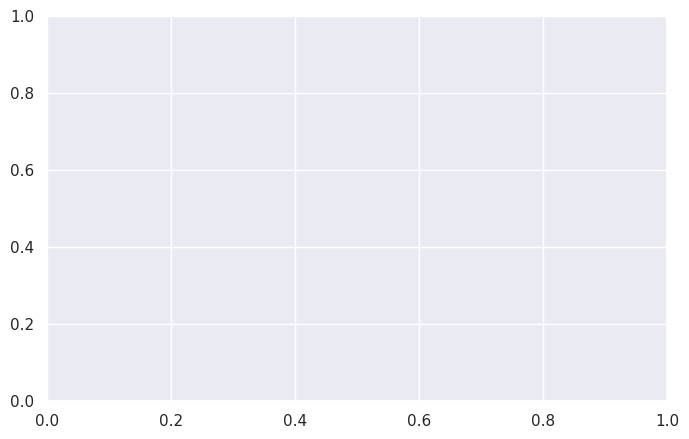

In [14]:
boxplot(col_comb)

**The plot illustrates**

das_temp is the most dramatic change

cavity_temp, etalon_temp, warmbox_temp:
 remain largely uconsistent, stay within a stable range, flatten out.

#==============#
ML data prepare
#==============#

In [15]:
flag_data = duckdb.sql(f"""
        SELECT
            ch4_flag
        FROM '{parquet_filename}'    
""").df()

In [16]:
flag_data.value_counts()

ch4_flag
            5651604
x            825585
F            252093
*              7495
Name: count, dtype: int64

In [17]:
flag_data.isna().mean()*100

ch4_flag    1.350317
dtype: float64

In [18]:
# NAN -> label1 = 1
mapping={" ":0, 
          "x":1, 
          "*":1,
          "F":1,  
        }
processed_data['label1'] = (processed_data['ch4_flag'].map(mapping).fillna(0)).astype(int)

In [19]:
processed_data.tail(30)

,date,time,type,sample,standard,port,ch4_dry,ch4_wet,ch4_stdev,ch4_std_rep,ch4_std_stdev,ch4_target_error,ch4_Cdrift,ch4_C,ch4_N,ch4_Nfiltered,cycle_time,h2o,h2o_stdev,cavity_press,cavity_press_stdev,cavity_temp,cavity_temp_stdev,das_temp,etalon_temp,warmbox_temp,outlet_valve,ch4_flag,label1
6828960,250722,64130,air,100m,CFF-011,9,2089.312,2088.258,5.397,0.131,0.129,0.309,2090.950,2090.963,16,NaN,3.562,0.03813,0.00034,140.00737,0.01358,44.99900,0.00000,32.68800,45.07194,45.00025,33818.500,,0
6828961,250722,64230,air,100m,CFF-011,9,2093.145,2092.079,2.866,0.131,0.129,0.309,2094.786,2094.800,17,NaN,3.471,0.03847,0.00051,139.99612,0.01200,44.99912,0.00033,32.66447,45.07271,45.00082,33815.230,,0
6828962,250722,64330,air,100m,CFF-011,9,2089.782,2088.723,2.150,0.131,0.129,0.309,2091.421,2091.434,16,NaN,3.625,0.03831,0.00048,139.99713,0.01529,44.99944,0.00051,32.62956,45.07300,45.00100,33814.109,,0
6828963,250722,64430,air,185m,CFF-011,10,2076.611,2075.536,6.131,0.130,0.129,0.309,2078.239,2078.246,0,100.0,3.688,0.03912,0.00062,140.00238,0.02193,44.99994,0.00025,32.62500,45.07338,45.00100,33699.598,x,1
6828964,250722,64530,air,185m,CFF-011,10,2078.204,2077.138,5.048,0.130,0.129,0.309,2079.833,2079.841,0,100.0,3.625,0.03875,0.00045,139.99887,0.01115,44.99969,0.00048,32.62487,45.07319,45.00100,33677.266,x,1
6828965,250722,64630,air,185m,CFF-011,10,2084.367,2083.292,3.380,0.130,0.129,0.309,2086.002,2086.012,16,NaN,3.562,0.03900,0.00063,139.99326,0.01312,44.99994,0.00025,32.62500,45.07300,45.00100,33670.773,,0
6828966,250722,64730,air,185m,CFF-011,10,2079.664,2078.589,4.984,0.130,0.129,0.309,2081.295,2081.303,17,NaN,3.471,0.03906,0.00043,140.00224,0.01230,44.99994,0.00024,32.62500,45.07300,45.00088,33670.941,,0
6828967,250722,64830,air,185m,CFF-011,10,2081.779,2080.703,4.049,0.130,0.129,0.309,2083.411,2083.421,16,NaN,3.562,0.03906,0.00025,139.99519,0.01692,45.00000,0.00000,32.62500,45.07300,45.00006,33662.199,,0
6828968,250722,64930,air,185m,CFF-011,10,2073.267,2072.197,8.502,0.130,0.129,0.309,2074.893,2074.898,17,NaN,3.471,0.03900,0.00000,139.99930,0.01630,45.00000,0.00000,32.62500,45.07288,45.00000,33660.953,,0
6828969,250722,65030,air,185m,CFF-011,10,2074.858,2073.787,3.877,0.130,0.129,0.309,2076.485,2076.491,16,NaN,3.625,0.03900,0.00000,140.00349,0.01737,45.00000,0.00000,32.64781,45.07300,45.00019,33661.648,,0


0609 --- end

#==============#
ML data prepare
#=============#

In [20]:
processed_data.head(20)

,date,time,type,sample,standard,port,ch4_dry,ch4_wet,ch4_stdev,ch4_std_rep,ch4_std_stdev,ch4_target_error,ch4_Cdrift,ch4_C,ch4_N,ch4_Nfiltered,cycle_time,h2o,h2o_stdev,cavity_press,cavity_press_stdev,cavity_temp,cavity_temp_stdev,das_temp,etalon_temp,warmbox_temp,outlet_valve,ch4_flag,label1
0,120111,162730,unknown,-,USN-20112109,0,1944.517,1945.109,42.208,NaN,NaN,NaN,1955.510,1955.527,0,100.0,3.733,-0.02232,0.00175,140.00525,0.01396,44.90277,0.01251,32.14167,44.77072,NaN,31442.617,x,1
1,120111,162830,unknown,-,USN-20112109,0,1972.043,1972.643,57.714,NaN,NaN,NaN,1983.192,1983.217,0,100.0,3.733,-0.02232,0.00170,140.00435,0.01518,44.92952,0.00415,32.36250,44.91882,NaN,31543.971,x,1
2,120111,162930,unknown,-,USN-20112109,0,1940.176,1940.768,65.419,NaN,NaN,NaN,1951.144,1951.159,0,100.0,3.733,-0.02243,0.00221,140.00513,0.01176,44.93352,0.00128,32.59792,44.99702,NaN,31626.549,x,1
3,120111,163030,unknown,-,USN-20112109,0,2021.915,2022.526,80.016,NaN,NaN,NaN,2033.346,2033.386,0,100.0,3.733,-0.02217,0.00256,140.00745,0.01437,44.92616,0.00253,32.81506,45.02549,NaN,31687.379,x,1
4,120111,163130,unknown,-,USN-20112109,0,1976.217,1976.825,57.151,NaN,NaN,NaN,1987.390,1987.416,0,100.0,3.625,-0.02259,0.00192,140.00314,0.01321,44.91914,0.00165,32.98813,45.02443,NaN,31726.805,x,1
5,120111,163230,unknown,-,USN-20112109,0,1977.023,1977.629,107.839,NaN,NaN,NaN,1988.200,1988.226,0,100.0,3.733,-0.02248,0.00258,139.99792,0.01910,44.91655,0.00026,33.13750,45.00900,NaN,31758.904,F,1
6,120111,163330,unknown,-,USN-20112109,0,1974.220,1974.855,94.284,NaN,NaN,NaN,1985.381,1985.406,0,100.0,3.500,-0.02362,0.00115,140.00032,0.01554,44.91776,0.00100,33.26172,44.98967,NaN,31785.496,F,1
7,120111,163430,unknown,-,USN-20112109,0,1904.261,1904.902,51.648,NaN,NaN,NaN,1915.027,1915.031,0,100.0,3.500,-0.02471,0.00000,140.00146,0.01652,44.92261,0.00181,33.35547,44.97134,NaN,31807.650,F,1
8,120111,163530,unknown,-,USN-20112109,0,1929.363,1930.012,59.736,NaN,NaN,NaN,1940.270,1940.282,0,100.0,3.500,-0.02471,0.00000,139.99977,0.01241,44.92999,0.00249,33.42248,44.95708,NaN,31827.049,F,1
9,120111,163630,unknown,-,USN-20112109,0,1970.042,1970.705,71.395,NaN,NaN,NaN,1981.180,1981.204,0,100.0,3.471,-0.02471,0.00000,140.00076,0.01586,44.93916,0.00306,33.47794,44.94679,NaN,31844.387,F,1


In [21]:
processed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6828990 entries, 0 to 6828989
Data columns (total 29 columns):
 #   Column              Dtype  
---  ------              -----  
 0   date                int64  
 1   time                int64  
 2   type                object 
 3   sample              object 
 4   standard            object 
 5   port                int64  
 6   ch4_dry             float64
 7   ch4_wet             float64
 8   ch4_stdev           float64
 9   ch4_std_rep         float64
 10  ch4_std_stdev       float64
 11  ch4_target_error    float64
 12  ch4_Cdrift          float64
 13  ch4_C               float64
 14  ch4_N               int64  
 15  ch4_Nfiltered       float64
 16  cycle_time          float64
 17  h2o                 float64
 18  h2o_stdev           float64
 19  cavity_press        float64
 20  cavity_press_stdev  float64
 21  cavity_temp         float64
 22  cavity_temp_stdev   float64
 23  das_temp            float64
 24  etalon_temp         floa

In [25]:
from sklearn.metrics import precision_recall_curve
def best_threshold(X_test, model, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * (precisions *recalls) / (precisions + recalls+ 1e-7) # 1e-7 to prevent Nan

    best_idx = np.argmax(f1_scores[:-1])
    best_thres = thresholds[best_idx]
    return best_thres, f1_scores[best_idx], precisions[best_idx], recalls[best_idx]
    #print(f"Best threshold: {best_threshold}")
    #print(f"Best F1-score: {f1_scores[best_idx]:.4f}")
    #print(f'Precision"{precisions[best_idx]:.4f}", Recall:{recalls[best_idx]}')

In [26]:
col_base=[
    # instrument state
    'cavity_temp', 'cavity_press', 'das_temp',
    'etalon_temp', 'warmbox_temp',
    # std
    'ch4_std_stdev', 'h2o_stdev',
    'cavity_press_stdev', 'cavity_temp_stdev',
    #h2o
    'h2o',
    #process
    'outlet_valve', 'cycle_time'
]
# without std
col_nostd=[
    'port',
    # instrument state
    'cavity_temp', 'cavity_press', 'das_temp',
    'etalon_temp', 'warmbox_temp',
    # std
    #'ch4_std_stdev', 'h2o_stdev',
    #'cavity_press_stdev', 'cavity_temp_stdev',
    #h2o
    'h2o',
    #process
    'outlet_valve', 'cycle_time'
]


In [27]:
feature_experiments = {
    #'col_base': col_base
    'col_nostd': col_nostd
}


In [29]:
import numpy as np

Model training...


2026/06/18 00:51:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/18 00:57:17 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_pro

Model training completed!
              precision    recall  f1-score   support

           0       0.90      0.99      0.95   1204069
           1       0.84      0.21      0.34    161729

    accuracy                           0.90   1365798
   macro avg       0.87      0.60      0.64   1365798
weighted avg       0.90      0.90      0.88   1365798



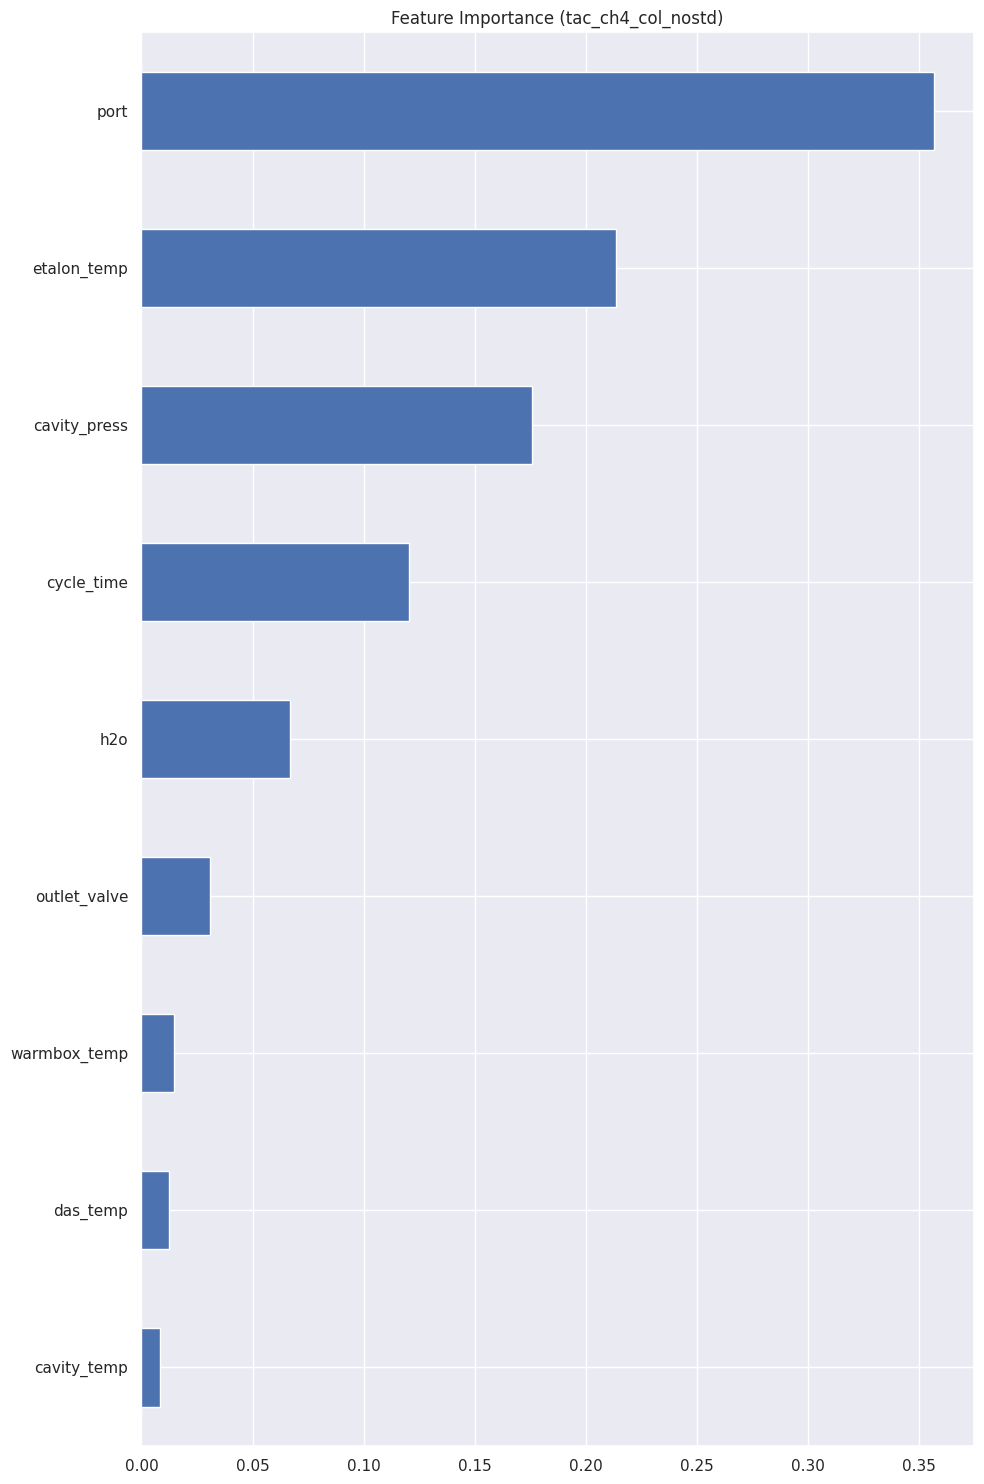

2026/06/18 00:58:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Best threshold: 0.29967437818778586
Best F1-score: 0.4613
Precision"0.5759", Recall:0.3847238281322459


In [30]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

for f, i  in feature_experiments.items() :
    X = processed_data[i]
    y = processed_data['label1']
    feature_cols = X.columns.tolist()
    split_idx = int(len(processed_data)*0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


    mlflow.set_experiment(f"{f}_update")
    print("Model training...")
    model = random_forest_model(
        X_train, y_train, X_test, y_test,
        feature_names=feature_cols,
        experiment_run_name=f'tac_ch4_{f}',n_estimators=200, max_depth=12, n_jobs=-1
    )
    best_threshold, best_f1, best_prec, best_rec = best_threshold(X_test, model, y_test)
    print(f"Best threshold: {best_threshold}")
    print(f"Best F1-score: {best_f1:.4f}")
    print(f'Precision"{best_prec:.4f}", Recall:{best_rec}')

the model is able to recgnize the obvious error data, but failed to spot subtle anomalies.

In [ ]:
initial_data = duckdb.sql(f"""
    SELECT 
        type,
        ch4_dry,
        ch4_wet,
        cavity_press,
        cavity_temp,
        CAST(warmbox_temp AS DOUBLE) as warmbox_temp_num
    FROM '{parquet_filename}'
""").df()
